# Assignment 1 (50 points)

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn as nn
from torch.nn import functional as F

## Problem 1 (20 points)

Optimize the following loss:
$L = (leaky\_relu(w1 * x1 + w2 * x2) - 5) ^ 2$

This represents a single neuron with 2 inputs (x1 and x2) with tunable parameters (w1 and w2). The neuron has leaky relu activation function defined below. The output should be equal to 5. We are measuring the loss using the L2 loss.


$\text{LeakyReLU}(x) = \begin{cases}
x, & \text{if } x > 0 \\
0.01 * x, & \text{otherwise}
\end{cases}$


Hints:
1. Since leaky relu is a piecewise function (is calculated different depending on the value of x), the derivative calculation will also be calculated differently depending on the value of x
2. Consider that:

$sum = w1 * x1 + w2 * x2$

$output = leaky\_relu(sum)$

$L = (output - 5) ^ 2$

How can we use the chain rule to $\frac{\delta L}{\delta w1}$ and $\frac{\delta L}{\delta w2}$?


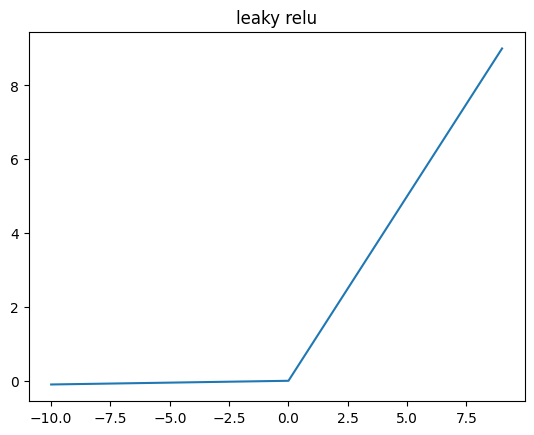

In [ ]:
def leaky_relu(x):
    if x > 0:
        return x
    else:
        return 0.01 * x

xs = np.arange(-10, 10)

ys = [leaky_relu(x) for x in xs]
plt.title('leaky relu')
plt.plot(xs, ys)

### 1a. Backpropagation by hand (10 points)
Optimize the loss using only python like we did in class. Derive the gradients by hand.

In [ ]:
# initialization

def leaky_relu_derivative(x):
    return 1 if x > 0 else 0.01

x1 = 5 # data
x2 = 6

w1 = 7 # model params
w2 = 8

lr = 0.01
target = 5

losses = []

for i in range(100):
    # implement here
    s = w1 * x1 + w2 * x2
    output = leaky_relu(s)
    loss = (output - target) ** 2
    losses.append(loss)

    # Backward pass (chain rule)
    dL_dout = 2 * (output - target)
    dout_ds = leaky_relu_derivative(s)

    dL_dw1 = dL_dout * dout_ds * x1
    dL_dw2 = dL_dout * dout_ds * x2

    # Update weights
    w1 -= lr * dL_dw1
    w2 -= lr * dL_dw2

    if i == 0 or i % 10 == 5:
        print(f"Iteration {i}: sum={s:.4f}, loss = {loss:.6f}, prediction={output:.4f}")

    pass


print(f"Prediction: ", leaky_relu(x1 * w1 + x2 * w2))

Iteration 0: sum=83.0000, loss = 6084.000000, prediction=83.0000
Iteration 5: sum=-11.9101, loss = 26.205196, prediction=-0.1191
Iteration 15: sum=-11.2859, loss = 26.141330, prediction=-0.1129
Iteration 25: sum=-10.6625, loss = 26.077619, prediction=-0.1066
Iteration 35: sum=-10.0398, loss = 26.014063, prediction=-0.1004
Iteration 45: sum=-9.4179, loss = 25.950662, prediction=-0.0942
Iteration 55: sum=-8.7968, loss = 25.887416, prediction=-0.0880
Iteration 65: sum=-8.1764, loss = 25.824324, prediction=-0.0818
Iteration 75: sum=-7.5567, loss = 25.761385, prediction=-0.0756
Iteration 85: sum=-6.9379, loss = 25.698600, prediction=-0.0694
Iteration 95: sum=-6.3197, loss = 25.635968, prediction=-0.0632
Prediction:  -0.06010965197584538


### 1b. Reimplement 1a using torch. (5 points)

Do not use `torch.optim`

In [ ]:
x1 = torch.tensor(3., requires_grad=False) # data
x2 = torch.tensor(4., requires_grad=False)

w1 = torch.tensor(5., requires_grad=True) # model params
w2 = torch.tensor(6., requires_grad=True)

lr = 0.01

for i in range(100):
    # implement
    s = x1 * w1 + x2 * w2
    output = F.leaky_relu(s, negative_slope=0.01)
    loss = (output - 5)**2

    loss.backward()

    with torch.no_grad():
        w1 -= lr * w1.grad
        w2 -= lr * w2.grad

        w1.grad.zero_()
        w2.grad.zero_()

    if i == 0 or i % 10 == 5:
        print(f"Iteration {i}: sum={s:.4f}, loss = {loss:.6f}, prediction={output:.4f}")
    pass

prediction = (F.leaky_relu(x1*w1 + x2*w2)).detach().item()

print(f"prediction: ", prediction)

Iteration 0: sum=39.0000, loss = 1156.000000, prediction=39.0000
Iteration 5: sum=6.0625, loss = 1.128906, prediction=6.0625
Iteration 15: sum=5.0010, loss = 0.000001, prediction=5.0010
Iteration 25: sum=5.0000, loss = 0.000000, prediction=5.0000
Iteration 35: sum=5.0000, loss = 0.000000, prediction=5.0000
Iteration 45: sum=5.0000, loss = 0.000000, prediction=5.0000
Iteration 55: sum=5.0000, loss = 0.000000, prediction=5.0000
Iteration 65: sum=5.0000, loss = 0.000000, prediction=5.0000
Iteration 75: sum=5.0000, loss = 0.000000, prediction=5.0000
Iteration 85: sum=5.0000, loss = 0.000000, prediction=5.0000
Iteration 95: sum=5.0000, loss = 0.000000, prediction=5.0000
prediction:  5.0


### 1c. Implement a 2 layer neural network. (5 points)

The neural network should be able to take inputs of size [4, 32] (batch size of 4 with 32 features per sample). The first layer should have have an output dimension of 8 and use the leaky relu activation. The second layer should not use an activation function.

Train the model so that it outputs 5. Use an L2 loss as we did in 1a and 1b.

[Pytorch docs on how to use leaky relu]("https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html")

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32, 8)
        self.fc2 = nn.Linear(8, 1)
        pass

    def forward(self, x):
        # implement
        x = F.leaky_relu(self.fc1(x), negative_slope=0.01)
        return self.fc2(x)
        pass

x = torch.randn((4, 32)).float()
target = torch.full((4, 1), 5.0)
net = MLP()
lr = 0.01

for _ in range(100):
    # implement
    pred = net(x)
    loss = ((pred - target)**2).mean()
    loss.backward()

    with torch.no_grad():
        for pm in net.parameters():
            pm -= lr * pm.grad
            pm.grad.zero_()

    if _ % 10 == 0:
      print(f"Iteration {_}: loss={loss.item():.6f}, out={pred.mean().item():.4f}")
    pass

prediction = net(x)
print(f"{prediction=}")

Iteration 0: loss=23.719831, out=0.1323
Iteration 10: loss=0.905146, out=4.1516
Iteration 20: loss=0.015045, out=4.9747
Iteration 30: loss=0.000796, out=4.9958
Iteration 40: loss=0.000048, out=4.9991
Iteration 50: loss=0.000003, out=4.9998
Iteration 60: loss=0.000000, out=5.0000
Iteration 70: loss=0.000000, out=5.0000
Iteration 80: loss=0.000000, out=5.0000
Iteration 90: loss=0.000000, out=5.0000
prediction=tensor([[5.0000],
        [5.0000],
        [5.0000],
        [5.0000]], grad_fn=<AddmmBackward0>)


## Problem 2 (30 points)

The objective is predict 0.6. This time, we will use an L1 loss, a sigmoid activation function, and 3 inputs instead. Specifically,


$prediction = sigmoid(w1 * x1 + w2 * x2 + w3 * x3)$

$loss = l1(prediction, 0.6)$

where $sigmoid$ and $l1$ is defined as:

$sigmoid(x) = \frac{1}{1+e^{-x}}$

and $l1(prediction, target) = absolute\_value(prediction - target)$

$\text{absolute_value}(x) = \begin{cases}
x, & \text{if } x > 0 \\
-x, & \text{otherwise}
\end{cases}$


Note that the absolute value function is a piece wise function, similar to leaky_relu.

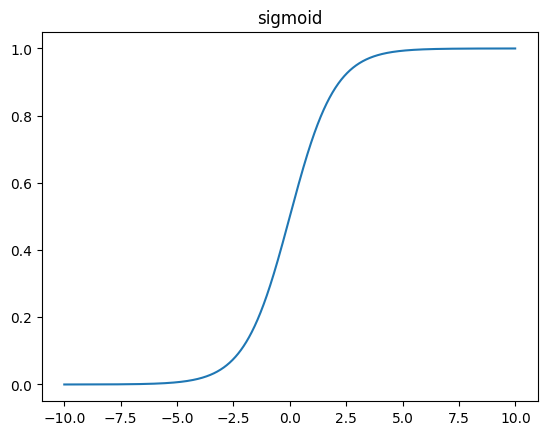

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

xs = np.arange(-10, 10, 0.01)

ys = [sigmoid(x) for x in xs]
plt.title('sigmoid')
plt.plot(xs, ys)

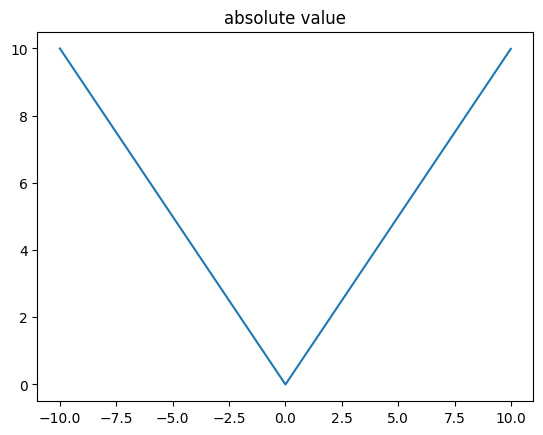

In [ ]:
def absolute_value(x):
    if x < 0:
        return -x
    else:
        return x

xs = np.arange(-10, 10, 0.01)

ys = [absolute_value(x) for x in xs]
plt.title('absolute value')
plt.plot(xs, ys)

### 2a. Backpropagation by hand (15 points)
Optimize the loss using only python like we did in class. Derive the gradients by hand.

In [ ]:
# initialization

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def l1_derivative(pred, target):
    if pred > target:
        return 1
    elif pred < target:
        return -1
    else:
        return 0

x1, x2, x3 = 0.5, 0.6, 0.7 # data
w1, w2, w3 = 0.7, 0.8, 0.9 # model
target = 0.6
lr = 0.01

for i in range(100):
    # implement here
    z = x1*w1 + x2*w2 + x3*w3
    pred = sigmoid(z)
    loss = abs(pred - target)

    dL_dpred = l1_derivative(pred, target)
    dpred_dz = sigmoid_derivative(z)

    dL_dw1 = dL_dpred * dpred_dz * x1
    dL_dw2 = dL_dpred * dpred_dz * x2
    dL_dw3 = dL_dpred * dpred_dz * x3

    w1 -= lr * dL_dw1
    w2 -= lr * dL_dw2
    w3 -= lr * dL_dw3

    pass


print(f"Prediction: ",sigmoid(x1 * w1 + x2 * w2 + x3 * w3))

Prediction:  0.7829040347865712


### 2b. Reimplement 2a using torch. (5 points)

Do not use `torch.optim`

In [ ]:
# implement here (follow the structure of 1b)

x1 = torch.tensor(0.5)
x2 = torch.tensor(0.6)
x3 = torch.tensor(0.7)
w1 = torch.tensor(0.7, requires_grad=True)
w2 = torch.tensor(0.8, requires_grad=True)
w3 = torch.tensor(0.9, requires_grad=True)
lr = 0.01
target = torch.tensor(0.6)

for i in range(100):
    z = x1 * w1 + x2 * w2 + x3 * w3
    pred = torch.sigmoid(z)
    loss = torch.abs(pred - target)

    loss.backward()

    with torch.no_grad():
        w1 -= lr * w1.grad
        w2 -= lr * w2.grad
        w3 -= lr * w3.grad
        w1.grad.zero_()
        w2.grad.zero_()
        w3.grad.zero_()

    if i == 0 or i % 10 == 5:
      print(f"Iteration {i}: sum={z:.4f}, loss = {loss:.6f}, prediction={pred:.4f}")
    pass

print(f"Prediction:", torch.sigmoid(x1 * w1 + x2 * w2 + x3 * w3).item())


Iteration 0: sum=1.4600, loss = 0.211533, prediction=0.8115
Iteration 5: sum=1.4516, loss = 0.210240, prediction=0.8102
Iteration 15: sum=1.4346, loss = 0.207613, prediction=0.8076
Iteration 25: sum=1.4174, loss = 0.204931, prediction=0.8049
Iteration 35: sum=1.4001, loss = 0.202192, prediction=0.8022
Iteration 45: sum=1.3825, loss = 0.199394, prediction=0.7994
Iteration 55: sum=1.3648, loss = 0.196537, prediction=0.7965
Iteration 65: sum=1.3469, loss = 0.193618, prediction=0.7936
Iteration 75: sum=1.3288, loss = 0.190638, prediction=0.7906
Iteration 85: sum=1.3105, loss = 0.187593, prediction=0.7876
Iteration 95: sum=1.2920, loss = 0.184484, prediction=0.7845
Prediction: 0.7829039692878723


### 2c. Implement a 2 layer neural network. (10 points)

The neural network should be able to take inputs of size [4, 32] (batch size of 4 with 32 features per sample). The first layer should have have an output dimension of 8 and use the sigmoid activation. The second layer should also use a sigmoid activation function.

Train the model so that it outputs 0.6. Use an L2 loss as we did in 1a and 1b.

[PyTorch docs for how to use sigmoid](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html)

In [ ]:
# implement here (follow the structure of 1c)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

x = torch.randn((4, 32)).float()
target = torch.full((4, 1), 0.6)
net = MLP()
lr = 0.1

for i in range(100):
    pred = net(x)
    loss = ((pred - target)**2).mean()
    loss.backward()

    with torch.no_grad():
        for pm in net.parameters():
            pm -= lr * pm.grad
            pm.grad.zero_()

    if i % 10 == 0:
            print(f"Iter {i}: loss={loss.item():.6f}, prediction={prediction.mean().item():.4f}")

prediction = net(x)
print(f"{prediction=}")


Iter 0: loss=0.011901, prediction=5.0000
Iter 10: loss=0.005093, prediction=5.0000
Iter 20: loss=0.002224, prediction=5.0000
Iter 30: loss=0.001006, prediction=5.0000
Iter 40: loss=0.000480, prediction=5.0000
Iter 50: loss=0.000250, prediction=5.0000
Iter 60: loss=0.000147, prediction=5.0000
Iter 70: loss=0.000099, prediction=5.0000
Iter 80: loss=0.000076, prediction=5.0000
Iter 90: loss=0.000065, prediction=5.0000
prediction=tensor([[0.6074],
        [0.5948],
        [0.5880],
        [0.6020]], grad_fn=<SigmoidBackward0>)
